# Phase 6 – Inventory Risk Scoring

This phase combines demand forecasting and inventory information to identify SKU-level stockout and overstock risks. Risk scores and recommended inventory actions are generated to support inventory planning and business decision-making.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
inventory_df = pd.read_csv(
    "../data/processed/inventory_snapshot_clean.csv"
)

print("Inventory dataset loaded successfully.")
print("Shape:", inventory_df.shape)

Inventory dataset loaded successfully.
Shape: (26408, 6)


In [3]:
model_df = pd.read_csv(
    "../data/processed/model_dataset.csv"
)

print("Model dataset loaded successfully.")
print("Shape:", model_df.shape)

Model dataset loaded successfully.
Shape: (9932614, 47)


In [4]:
print("Inventory Dataset Columns:")
print(inventory_df.columns.tolist())

Inventory Dataset Columns:
['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']


In [5]:
print("Model Dataset Columns:")
print(model_df.columns.tolist())

Model Dataset Columns:
['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id', 'year', 'month', 'quarter', 'week', 'day_of_week', 'is_weekend', 'total_quantity', 'total_sales', 'average_price', 'total_transactions', 'sku_name', 'category', 'subcategory', 'unit_price_sku', 'cost_price', 'brand', 'total_spent', 'total_quantity_customer', 'total_transactions_customer', 'average_transaction_value', 'cust_id', 'age', 'gender', 'city', 'loyalty_segment', 'preferred_channel', 'registration_date', 'total_sales_store', 'total_quantity_store', 'total_transactions_store', 'average_order_value', 'store_name', 'city_store', 'store_type', 'opening_date', 'promotion_used']


In [6]:
inventory_df.head()

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,333,72,22,2025-06-23
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,496,96,34,2025-07-10
3,ST19,SKU02907,109,34,13,2025-08-17
4,ST05,SKU01023,333,97,22,2025-07-12


In [7]:
model_df.head()

,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,...,registration_date,total_sales_store,total_quantity_store,total_transactions_store,average_order_value,store_name,city_store,store_type,opening_date,promotion_used
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,...,2020-09-29,2.575954e+08,443525,235843,1092.232527,Lahore Convenience Store #16,Lahore,Convenience Store,2016-06-07,False
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,...,2020-09-29,2.575954e+08,443525,235843,1092.232527,Lahore Convenience Store #16,Lahore,Convenience Store,2016-06-07,False
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,...,2025-10-12,2.574381e+08,442257,234792,1096.451818,Islamabad Convenience Store #15,Islamabad,Convenience Store,2020-05-11,False
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,...,2025-10-12,2.574381e+08,442257,234792,1096.451818,Islamabad Convenience Store #15,Islamabad,Convenience Store,2020-05-11,False
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,...,2022-07-10,5.140385e+08,886423,471308,1090.663659,Multan Hypermarket #20,Multan,Hypermarket,2017-06-30,False


In [8]:
print("Inventory Missing Values:")
print(inventory_df.isnull().sum())

print("\nModel Dataset Missing Values:")
print(model_df.isnull().sum())

Inventory Missing Values:
store_id             0
sku_id               0
stock_on_hand        0
reorder_point        0
safety_stock         0
last_restock_date    0
dtype: int64

Model Dataset Missing Values:
date                                 0
receipt_id                           0
store_id                             0
sku_id                               0
customer_id                          0
quantity                             0
unit_price                           0
total_value                          0
channel                              0
discount_pct                         0
promo_id                       7845164
year                                 0
month                                0
quarter                              0
week                                 0
day_of_week                          0
is_weekend                           0
total_quantity                       0
total_sales                          0
average_price                        0
total_transa

### Section 1 Summary

The inventory and forecasting datasets were loaded from the processed data directory. Dataset dimensions, column names, sample records, and missing values were examined to confirm that the required data is available for inventory risk scoring. The datasets will be combined in the next section using their appropriate SKU and time identifiers.

In [9]:
demand_summary = (
    model_df
    .groupby(["store_id", "sku_id"])
    .agg(
        total_quantity=("quantity", "sum"),
        average_weekly_demand=("quantity", "mean"),
        total_sales=("total_value", "sum"),
        average_unit_price=("unit_price", "mean"),
        cost_price=("cost_price", "mean")
    )
    .reset_index()
)

print("Demand summary shape:", demand_summary.shape)

demand_summary.head()

Demand summary shape: (150000, 7)


,store_id,sku_id,total_quantity,average_weekly_demand,total_sales,average_unit_price,cost_price
0,ST01,SKU00001,107,1.945455,79404.27,813.41,619.77
1,ST01,SKU00002,943,1.940329,62942.68,70.38,49.57
2,ST01,SKU00003,29,2.071429,3887.75,151.28,83.67
3,ST01,SKU00004,67,1.914286,14660.20,233.64,156.32
4,ST01,SKU00005,66,2.000000,8910.66,138.50,83.46


In [10]:
print(
    "Duplicate store-SKU combinations:",
    demand_summary.duplicated(["store_id", "sku_id"]).sum()
)

Duplicate store-SKU combinations: 0


In [11]:
risk_df = inventory_df.merge(
    demand_summary,
    on=["store_id", "sku_id"],
    how="left"
)

print("Risk dataset shape:", risk_df.shape)

risk_df.head()

Risk dataset shape: (26408, 11)


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date,total_quantity,average_weekly_demand,total_sales,average_unit_price,cost_price
0,ST11,SKU02558,333,72,22,2025-06-23,48,2.086957,3978.68,87.70,67.29
1,ST21,SKU01031,236,67,14,2025-06-17,79,2.025641,51532.55,668.10,419.47
2,ST26,SKU02129,496,96,34,2025-07-10,13,1.444444,2702.81,227.28,138.59
3,ST19,SKU02907,109,34,13,2025-08-17,34,1.619048,48281.71,1495.16,1152.38
4,ST05,SKU01023,333,97,22,2025-07-12,42,2.000000,21192.67,526.16,382.68


In [12]:
print(risk_df.isnull().sum())

store_id                 0
sku_id                   0
stock_on_hand            0
reorder_point            0
safety_stock             0
last_restock_date        0
total_quantity           0
average_weekly_demand    0
total_sales              0
average_unit_price       0
cost_price               0
dtype: int64


In [13]:
print("Risk dataset shape:", risk_df.shape)
print(risk_df.isnull().sum())

Risk dataset shape: (26408, 11)
store_id                 0
sku_id                   0
stock_on_hand            0
reorder_point            0
safety_stock             0
last_restock_date        0
total_quantity           0
average_weekly_demand    0
total_sales              0
average_unit_price       0
cost_price               0
dtype: int64


## Section 2 – Demand and Inventory Integration

Historical sales transactions were aggregated at the store-SKU level to create demand indicators. The aggregated demand information was then merged with the inventory snapshot using `store_id` and `sku_id`. This prevents transaction-level duplication and creates a single analytical dataset for inventory risk scoring.

In [14]:
risk_df["inventory_coverage_weeks"] = (
    risk_df["stock_on_hand"] /
    risk_df["average_weekly_demand"].replace(0, np.nan)
)

risk_df["inventory_coverage_weeks"] = (
    risk_df["inventory_coverage_weeks"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print(risk_df["inventory_coverage_weeks"].describe())

count    26408.000000
mean        90.038912
std         78.853073
min          0.000000
25%         21.364704
50%         74.608696
75%        141.906349
max        535.000000
Name: inventory_coverage_weeks, dtype: float64


In [15]:
risk_df[
    [
        "store_id",
        "sku_id",
        "stock_on_hand",
        "average_weekly_demand",
        "inventory_coverage_weeks"
    ]
].head(10)

,store_id,sku_id,stock_on_hand,average_weekly_demand,inventory_coverage_weeks
0,ST11,SKU02558,333,2.086957,159.562500
1,ST21,SKU01031,236,2.025641,116.506329
2,ST26,SKU02129,496,1.444444,343.384615
3,ST19,SKU02907,109,1.619048,67.323529
4,ST05,SKU01023,333,2.000000,166.500000
5,ST08,SKU04475,345,2.666667,129.375000
6,ST01,SKU01318,92,2.111111,43.578947
7,ST13,SKU00389,212,2.000000,106.000000
8,ST25,SKU01675,289,1.800000,160.555556
9,ST06,SKU01396,251,1.703704,147.326087


In [16]:
print(
    "Negative coverage:",
    (risk_df["inventory_coverage_weeks"] < 0).sum()
)

print(
    "Zero coverage:",
    (risk_df["inventory_coverage_weeks"] == 0).sum()
)

print(
    "Missing coverage:",
    risk_df["inventory_coverage_weeks"].isnull().sum()
)

Negative coverage: 0
Zero coverage: 4239
Missing coverage: 0


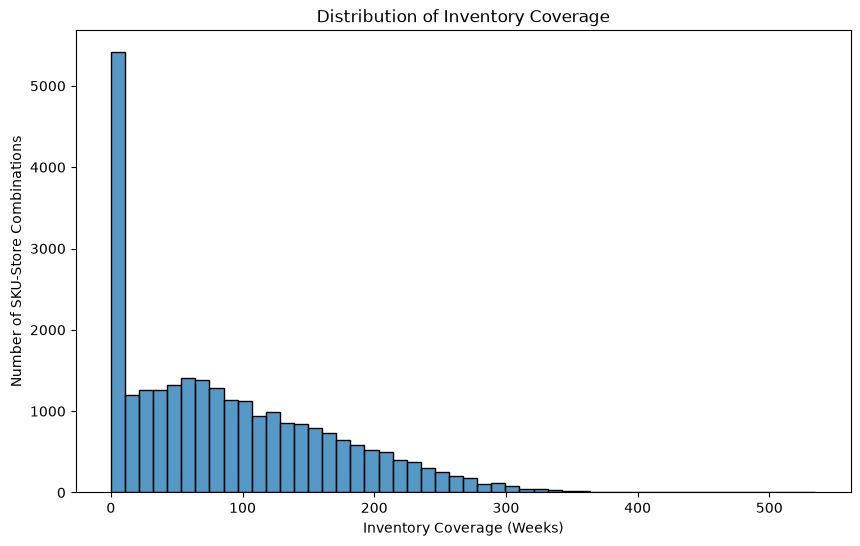

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    risk_df["inventory_coverage_weeks"],
    bins=50
)

plt.title("Distribution of Inventory Coverage")
plt.xlabel("Inventory Coverage (Weeks)")
plt.ylabel("Number of SKU-Store Combinations")

plt.show()

In [18]:
risk_df[
    [
        "store_id",
        "sku_id",
        "stock_on_hand",
        "average_weekly_demand",
        "inventory_coverage_weeks"
    ]
].sort_values(
    "inventory_coverage_weeks"
).head(10)

,store_id,sku_id,stock_on_hand,average_weekly_demand,inventory_coverage_weeks
4947,ST15,SKU00506,0,1.945455,0.0
4934,ST14,SKU04627,0,1.896203,0.0
24078,ST04,SKU02660,0,1.853191,0.0
24074,ST04,SKU03633,0,1.887097,0.0
24070,ST09,SKU02355,0,1.966767,0.0
24069,ST04,SKU01507,0,1.907923,0.0
4931,ST20,SKU00500,0,1.908517,0.0
17180,ST19,SKU02614,0,1.954802,0.0
4966,ST09,SKU01371,0,1.896685,0.0
24068,ST29,SKU00976,0,1.983834,0.0


### Section 3 Summary

Inventory coverage was calculated by dividing stock on hand by average weekly demand. This metric provides an estimate of the number of weeks that current inventory can support expected demand. SKU-store combinations with very low coverage require further investigation for potential stockout risk, while unusually high coverage may indicate potential overstock.

In [19]:
risk_df["inventory_coverage_weeks"].describe()

count    26408.000000
mean        90.038912
std         78.853073
min          0.000000
25%         21.364704
50%         74.608696
75%        141.906349
max        535.000000
Name: inventory_coverage_weeks, dtype: float64

In [20]:
risk_df["stockout_risk"] = np.select(
    [
        risk_df["stock_on_hand"] <= risk_df["safety_stock"],
        risk_df["stock_on_hand"] <= risk_df["reorder_point"]
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

risk_df["stockout_risk"].value_counts()

stockout_risk
Low       19246
High       5270
Medium     1892
Name: count, dtype: int64

In [21]:
risk_df[
    [
        "store_id",
        "sku_id",
        "stock_on_hand",
        "safety_stock",
        "reorder_point",
        "inventory_coverage_weeks",
        "stockout_risk"
    ]
].head(20)

,store_id,sku_id,stock_on_hand,safety_stock,reorder_point,inventory_coverage_weeks,stockout_risk
0,ST11,SKU02558,333,22,72,159.562500,Low
1,ST21,SKU01031,236,14,67,116.506329,Low
2,ST26,SKU02129,496,34,96,343.384615,Low
3,ST19,SKU02907,109,13,34,67.323529,Low
4,ST05,SKU01023,333,22,97,166.500000,Low
5,ST08,SKU04475,345,29,90,129.375000,Low
6,ST01,SKU01318,92,9,24,43.578947,Low
7,ST13,SKU00389,212,15,49,106.000000,Low
8,ST25,SKU01675,289,32,77,160.555556,Low
9,ST06,SKU01396,251,12,57,147.326087,Low


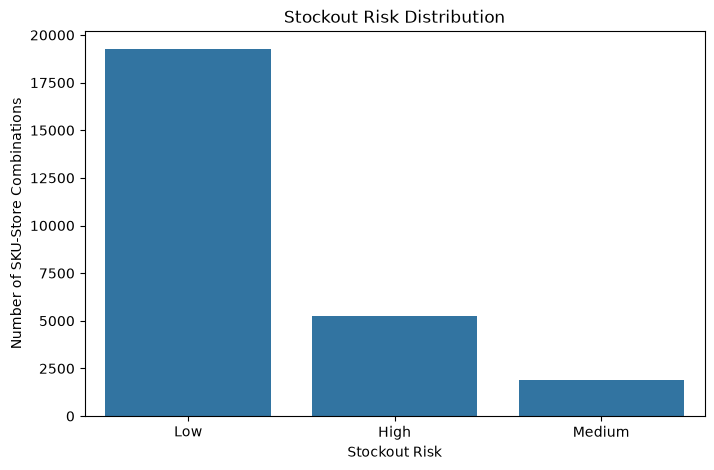

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=risk_df,
    x="stockout_risk"
)

plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk")
plt.ylabel("Number of SKU-Store Combinations")

plt.show()

### Stockout Risk Summary

Stockout risk was classified using the available inventory controls. SKU-store combinations with stock on hand at or below the safety stock level were classified as High Risk. Combinations above safety stock but at or below the reorder point were classified as Medium Risk. Remaining combinations were classified as Low Risk.

This classification provides a transparent basis for prioritising replenishment decisions.

In [23]:
risk_df["overstock_risk"] = np.select(
    [
        risk_df["inventory_coverage_weeks"] >= 26,
        risk_df["inventory_coverage_weeks"] >= 13
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

risk_df["overstock_risk"].value_counts()

overstock_risk
High      19274
Low        5682
Medium     1452
Name: count, dtype: int64

In [24]:
risk_df[
    [
        "store_id",
        "sku_id",
        "stock_on_hand",
        "average_weekly_demand",
        "inventory_coverage_weeks",
        "overstock_risk"
    ]
].sort_values(
    "inventory_coverage_weeks",
    ascending=False
).head(20)

,store_id,sku_id,stock_on_hand,average_weekly_demand,inventory_coverage_weeks,overstock_risk
21657,ST10,SKU00598,535,1.000000,535.000000,High
22152,ST02,SKU03173,570,1.166667,488.571429,High
21844,ST26,SKU00585,512,1.100000,465.454545,High
11714,ST15,SKU01645,556,1.200000,463.333333,High
11243,ST25,SKU00679,557,1.285714,433.222222,High
1306,ST10,SKU02112,425,1.000000,425.000000,High
25199,ST10,SKU01423,576,1.357143,424.421053,High
22473,ST26,SKU00012,574,1.357143,422.947368,High
2887,ST27,SKU04894,555,1.312500,422.857143,High
22141,ST25,SKU03583,543,1.300000,417.692308,High


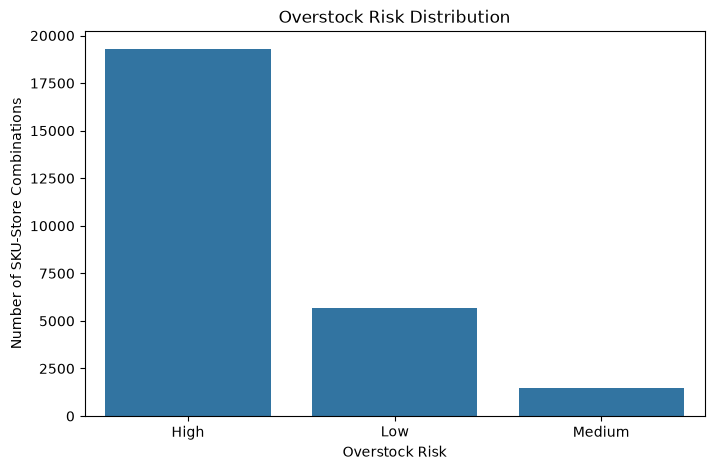

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=risk_df,
    x="overstock_risk"
)

plt.title("Overstock Risk Distribution")
plt.xlabel("Overstock Risk")
plt.ylabel("Number of SKU-Store Combinations")

plt.show()

### Overstock Risk Summary

Overstock risk was assessed using inventory coverage in weeks. SKU-store combinations with at least 26 weeks of inventory coverage were classified as High Overstock Risk, while combinations with 13 to 26 weeks were classified as Medium Overstock Risk. Remaining combinations were classified as Low Overstock Risk.

The classification highlights SKUs with potentially excessive inventory relative to historical demand and provides a basis for inventory reduction and replenishment planning.

In [26]:
risk_df["risk_score"] = np.select(
    [
        risk_df["stockout_risk"] == "High",
        risk_df["overstock_risk"] == "High",
        risk_df["stockout_risk"] == "Medium",
        risk_df["overstock_risk"] == "Medium"
    ],
    [
        3,
        3,
        2,
        2
    ],
    default=1
)

risk_df["risk_level"] = np.select(
    [
        risk_df["risk_score"] == 3,
        risk_df["risk_score"] == 2
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

risk_df["risk_level"].value_counts()

risk_level
High      24543
Medium     1841
Low          24
Name: count, dtype: int64

In [27]:
risk_df["recommended_action"] = np.select(
    [
        risk_df["stockout_risk"] == "High",
        risk_df["stockout_risk"] == "Medium",
        risk_df["overstock_risk"] == "High",
        risk_df["overstock_risk"] == "Medium"
    ],
    [
        "Reorder urgently",
        "Review replenishment",
        "Reduce replenishment",
        "Monitor inventory"
    ],
    default="Maintain normal stock"
)

risk_df["recommended_action"].value_counts()

recommended_action
Reduce replenishment     18675
Reorder urgently          5270
Review replenishment      1892
Monitor inventory          547
Maintain normal stock       24
Name: count, dtype: int64

In [28]:
risk_df[
    [
        "store_id",
        "sku_id",
        "stock_on_hand",
        "reorder_point",
        "safety_stock",
        "average_weekly_demand",
        "inventory_coverage_weeks",
        "stockout_risk",
        "overstock_risk",
        "risk_score",
        "risk_level",
        "recommended_action"
    ]
].head(20)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,average_weekly_demand,inventory_coverage_weeks,stockout_risk,overstock_risk,risk_score,risk_level,recommended_action
0,ST11,SKU02558,333,72,22,2.086957,159.562500,Low,High,3,High,Reduce replenishment
1,ST21,SKU01031,236,67,14,2.025641,116.506329,Low,High,3,High,Reduce replenishment
2,ST26,SKU02129,496,96,34,1.444444,343.384615,Low,High,3,High,Reduce replenishment
3,ST19,SKU02907,109,34,13,1.619048,67.323529,Low,High,3,High,Reduce replenishment
4,ST05,SKU01023,333,97,22,2.000000,166.500000,Low,High,3,High,Reduce replenishment
5,ST08,SKU04475,345,90,29,2.666667,129.375000,Low,High,3,High,Reduce replenishment
6,ST01,SKU01318,92,24,9,2.111111,43.578947,Low,High,3,High,Reduce replenishment
7,ST13,SKU00389,212,49,15,2.000000,106.000000,Low,High,3,High,Reduce replenishment
8,ST25,SKU01675,289,77,32,1.800000,160.555556,Low,High,3,High,Reduce replenishment
9,ST06,SKU01396,251,57,12,1.703704,147.326087,Low,High,3,High,Reduce replenishment


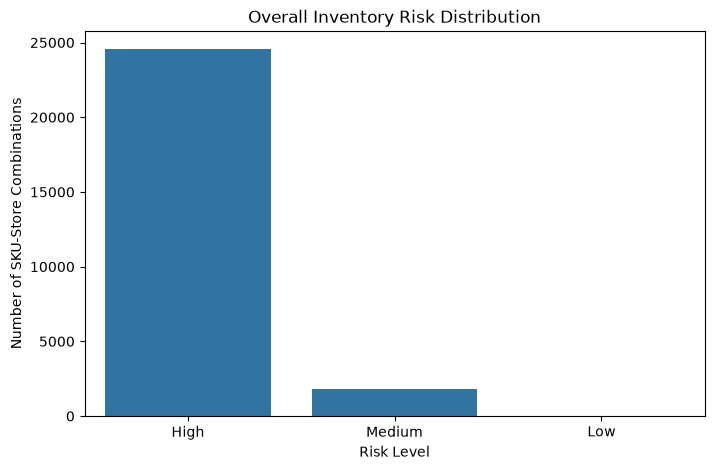

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=risk_df,
    x="risk_level",
    order=["High", "Medium", "Low"]
)

plt.title("Overall Inventory Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of SKU-Store Combinations")

plt.show()

### Combined Risk Summary

A combined risk framework was created using stockout and overstock indicators. High-priority stockout conditions receive the highest risk score because insufficient inventory can directly affect product availability. High inventory coverage is also flagged because excessive inventory may increase holding costs and working-capital requirements.

Each SKU-store combination is assigned a risk level and a recommended inventory action to support prioritised decision-making.

In [30]:
risk_df["recommended_action"].value_counts()

recommended_action
Reduce replenishment     18675
Reorder urgently          5270
Review replenishment      1892
Monitor inventory          547
Maintain normal stock       24
Name: count, dtype: int64

In [31]:
risk_df[
    [
        "store_id",
        "sku_id",
        "stock_on_hand",
        "reorder_point",
        "safety_stock",
        "average_weekly_demand",
        "inventory_coverage_weeks",
        "stockout_risk",
        "overstock_risk",
        "risk_score",
        "risk_level",
        "recommended_action"
    ]
].head(20)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,average_weekly_demand,inventory_coverage_weeks,stockout_risk,overstock_risk,risk_score,risk_level,recommended_action
0,ST11,SKU02558,333,72,22,2.086957,159.562500,Low,High,3,High,Reduce replenishment
1,ST21,SKU01031,236,67,14,2.025641,116.506329,Low,High,3,High,Reduce replenishment
2,ST26,SKU02129,496,96,34,1.444444,343.384615,Low,High,3,High,Reduce replenishment
3,ST19,SKU02907,109,34,13,1.619048,67.323529,Low,High,3,High,Reduce replenishment
4,ST05,SKU01023,333,97,22,2.000000,166.500000,Low,High,3,High,Reduce replenishment
5,ST08,SKU04475,345,90,29,2.666667,129.375000,Low,High,3,High,Reduce replenishment
6,ST01,SKU01318,92,24,9,2.111111,43.578947,Low,High,3,High,Reduce replenishment
7,ST13,SKU00389,212,49,15,2.000000,106.000000,Low,High,3,High,Reduce replenishment
8,ST25,SKU01675,289,77,32,1.800000,160.555556,Low,High,3,High,Reduce replenishment
9,ST06,SKU01396,251,57,12,1.703704,147.326087,Low,High,3,High,Reduce replenishment


### Combined Risk Summary

A combined risk framework was created using stockout and overstock indicators. High-priority stockout conditions receive the highest risk score because insufficient inventory can directly affect product availability. High inventory coverage is also flagged because excessive inventory may increase holding costs and working-capital requirements.

Each SKU-store combination is assigned a risk level and a recommended inventory action to support prioritised decision-making.

In [32]:
risk_df["inventory_value"] = (
    risk_df["stock_on_hand"] * risk_df["cost_price"]
)

print(risk_df["inventory_value"].describe())

count    2.640800e+04
mean     7.002542e+04
std      1.227870e+05
min      0.000000e+00
25%      5.744915e+03
50%      2.555803e+04
75%      7.427955e+04
max      1.743256e+06
Name: inventory_value, dtype: float64


In [33]:
risk_df["stockout_quantity_exposure"] = (
    risk_df["average_weekly_demand"] - risk_df["stock_on_hand"]
).clip(lower=0)

risk_df["stockout_value_exposure"] = (
    risk_df["stockout_quantity_exposure"] * risk_df["cost_price"]
)

print(
    "Total estimated stockout exposure:",
    round(risk_df["stockout_value_exposure"].sum(), 2)
)

Total estimated stockout exposure: 3243978.63


In [34]:
target_inventory = (
    risk_df["average_weekly_demand"] * 26
)

risk_df["excess_inventory_quantity"] = (
    risk_df["stock_on_hand"] - target_inventory
).clip(lower=0)

risk_df["excess_inventory_value"] = (
    risk_df["excess_inventory_quantity"] * risk_df["cost_price"]
)

print(
    "Estimated excess inventory value:",
    round(risk_df["excess_inventory_value"].sum(), 2)
)

Estimated excess inventory value: 1423294258.82


In [35]:
top_risks = (
    risk_df[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "average_weekly_demand",
            "inventory_coverage_weeks",
            "risk_level",
            "recommended_action",
            "inventory_value",
            "stockout_value_exposure",
            "excess_inventory_value"
        ]
    ]
    .sort_values(
        ["risk_level", "inventory_value"],
        ascending=[True, False]
    )
    .head(20)
)

top_risks

,store_id,sku_id,stock_on_hand,average_weekly_demand,inventory_coverage_weeks,risk_level,recommended_action,inventory_value,stockout_value_exposure,excess_inventory_value
25950,ST12,SKU03043,513,2.090909,245.347826,High,Reduce replenishment,1743256.08,0.0,1.558520e+06
3019,ST30,SKU03043,473,2.080000,227.403846,High,Reduce replenishment,1607329.68,0.0,1.423557e+06
1670,ST17,SKU03043,447,1.684211,265.406250,High,Reduce replenishment,1518977.52,0.0,1.370174e+06
648,ST27,SKU03043,426,2.173913,195.960000,High,Reduce replenishment,1447616.16,0.0,1.255546e+06
25988,ST04,SKU04062,518,1.777778,291.375000,High,Reduce replenishment,1413590.92,0.0,1.287453e+06
9343,ST18,SKU04062,510,1.739130,293.250000,High,Reduce replenishment,1391759.40,0.0,1.268364e+06
11595,ST10,SKU03043,404,1.666667,242.400000,High,Reduce replenishment,1372856.64,0.0,1.225603e+06
3900,ST17,SKU03150,482,1.363636,353.466667,High,Reduce replenishment,1321942.84,0.0,1.224704e+06
26235,ST14,SKU03043,389,1.920000,202.604167,High,Reduce replenishment,1321884.24,0.0,1.152248e+06
24487,ST25,SKU03150,477,1.714286,278.250000,High,Reduce replenishment,1308229.74,0.0,1.185987e+06


In [36]:
business_impact = pd.DataFrame({
    "Metric": [
        "Total SKU-Store combinations",
        "High Risk combinations",
        "Medium Risk combinations",
        "Low Risk combinations",
        "Total Inventory Value",
        "Estimated Stockout Exposure",
        "Estimated Excess Inventory Value"
    ],
    "Value": [
        len(risk_df),
        (risk_df["risk_level"] == "High").sum(),
        (risk_df["risk_level"] == "Medium").sum(),
        (risk_df["risk_level"] == "Low").sum(),
        risk_df["inventory_value"].sum(),
        risk_df["stockout_value_exposure"].sum(),
        risk_df["excess_inventory_value"].sum()
    ]
})

business_impact

,Metric,Value
0,Total SKU-Store combinations,2.640800e+04
1,High Risk combinations,2.454300e+04
2,Medium Risk combinations,1.841000e+03
3,Low Risk combinations,2.400000e+01
4,Total Inventory Value,1.849231e+09
5,Estimated Stockout Exposure,3.243979e+06
6,Estimated Excess Inventory Value,1.423294e+09


In [37]:
risk_df.to_csv(
    "../data/processed/risk_scoring_output.csv",
    index=False
)

print("Risk scoring dataset saved successfully!")

Risk scoring dataset saved successfully!


### Business Impact Summary

The risk-scoring dataset was enriched with inventory value, estimated stockout exposure, and estimated excess inventory value. These measures provide a business-oriented view of the potential financial impact associated with inventory risk.

The final SKU-store risk dataset has been saved as `risk_scoring_output.csv` and will serve as the analytical input for the planning dashboard and subsequent decision-support activities.